In [1]:
import sys
import numpy as np
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt

sys.path.append("../src")
import tensorflow_wavelets.Layers.DWT as DWT


In [2]:

url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=url, extract=True)
data_dir = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

# --- Parameters ---
image_size = (28, 28)
batch_size = 32
num_classes = 2
epochs = 30

# --- Image Generator ---
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# --- Model ---
model = keras.Sequential([
    keras.Input(shape=(*image_size, 1)),
    DWT.DWT(name="haar", concat=0),  # Your custom layer
    keras.layers.Flatten(),
    keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)


Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Epoch 1/30
75/75 [==============================] - 2s 21ms/step - loss: 0.6630 - accuracy: 0.6488 - val_loss: 0.6624 - val_accuracy: 0.6533
Epoch 2/30
75/75 [==============================] - 1s 19ms/step - loss: 0.6411 - accuracy: 0.6612 - val_loss: 0.6674 - val_accuracy: 0.6000
Epoch 3/30
75/75 [==============================] - 1s 19ms/step - loss: 0.6313 - accuracy: 0.6633 - val_loss: 0.6525 - val_accuracy: 0.6517
Epoch 4/30
75/75 [==============================] - 1s 19ms/step - loss: 0.6224 - accuracy: 0.6675 - val_loss: 0.6542 - val_accuracy: 0.6400
Epoch 5/30
75/75 [==============================] - 1s 19ms/step - loss: 0.6132 - accuracy: 0.6783 - val_loss: 0.6500 - val_accuracy: 0.6517
Epoch 6/30
75/75 [==============================] - 1s 19ms/step - loss: 0.6052 - accuracy: 0.6804 - val_loss: 0.6904 - val_accuracy: 0.5300
Epoch 7/30
75/75 [==============================] - 1s 20ms/step - loss

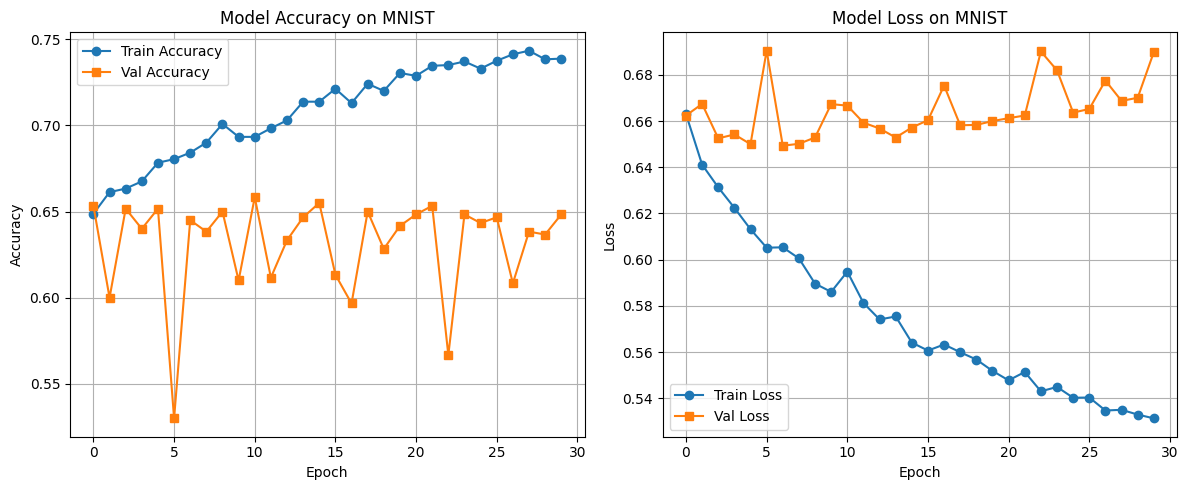

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Model Accuracy on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
